In [152]:
from IPython.display import display, Math
import numpy as np
from scipy import optimize as opt
import pandas as pd
from matplotlib import pyplot as plt
from fractions import Fraction

def closest_fraction(x, max_denominator):
    denominators = np.arange(2, max_denominator + 1).astype(int)
    numerators = np.round(denominators * x).astype(int)
    distances = np.abs(numerators - denominators * x)
    best_index = np.argmin(distances)
    return Fraction(numerators[best_index], denominators[best_index])

def closest_fractions(x, max_denominator):
    denominators = np.arange(2, max_denominator + 1).astype(int)
    numerators = np.round(np.outer(x, denominators)).astype(int)
    distances = np.abs(numerators - np.outer(x, denominators))
    best_indices = np.argmin(distances, axis=1)
    return [Fraction(numerators[i][best_indices[i]], denominators[best_indices[i]]) for i in range(len(x))]

In [2]:
def make_polynomial(alpha, degree):
    return [-1, 1] + [0] * (degree - 2)  + [alpha]

$$\alpha x^p + x - 1 = 0$$

In [262]:
degree = 7
num_alphas = 101
alphas = np.logspace(-20, 20, num_alphas)
roots = np.zeros((degree, num_alphas)).astype('complex')
last_roots = None
for k, alpha in enumerate(alphas):
    poly = make_polynomial(alpha, degree)
    current_roots = np.roots(poly)
    roots[:, k] = np.sort(current_roots)
    
roots = pd.DataFrame(roots.T, index=alphas)

args = roots.apply(np.angle) / np.pi
abss = roots.apply(np.abs)

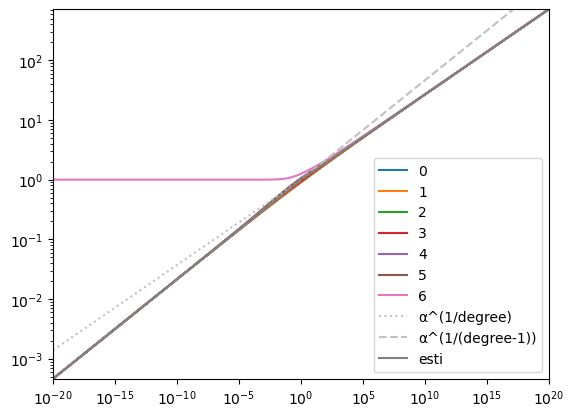

In [263]:
abss.plot()
plt.yscale("log")
plt.xscale("log")
plt.xlim(alphas.min(), alphas.max())
plt.ylim(abss.min().min(), abss.max().max())

maybes = (alphas ** (2 + 1/degree) +  alphas ** (1/(degree -1))) / (1 + alphas ** 2)

plt.plot(alphas, alphas ** (1/degree), color="silver", ls="dotted", label="α^(1/degree)")
plt.plot(alphas, alphas ** (1/(degree - 1)), color="silver", ls="dashed", label="α^(1/(degree-1))")
plt.plot(alphas, maybes, label="esti")
plt.legend()

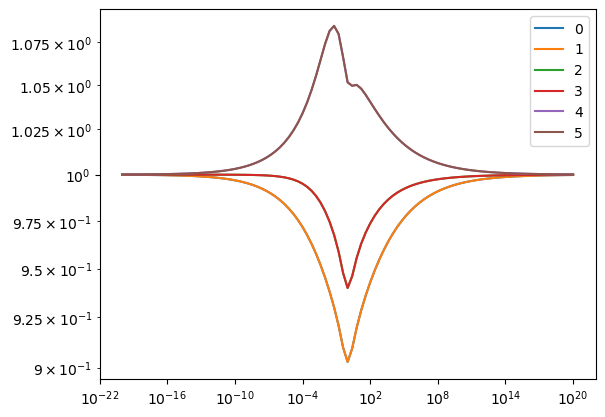

In [273]:
abss.apply(lambda x: x/ maybes).loc[:, 0:5].plot()
plt.yscale("log")
plt.xscale("log")


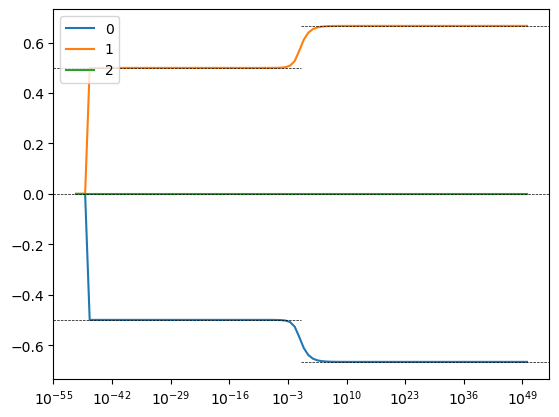

In [209]:
args.plot()
plt.xscale("log")

limit = (degree + 1) // 2

for k in range(1, limit):
    before_numerator = 2 * k  -  1
    after_numerator = 2 * k
    plt.axhline(before_numerator/(degree - 1), xmin=0, xmax=0.5, color="k", ls="--", lw=0.5)
    plt.axhline(after_numerator/(degree), xmin=0.5, xmax=1, color="k", ls="--", lw=0.5)

    plt.axhline(-before_numerator/(degree - 1), xmin=0, xmax=0.5, color="k", ls="--", lw=0.5)
    plt.axhline(-after_numerator/(degree), xmin=0.5, xmax=1, color="k", ls="--", lw=0.5)

plt.axhline(0, xmin=0, xmax=1, color="k", ls="--", lw=0.5)
    

# for k in range(1, limit)[::-1]:
#     display(Math(rf"\frac{{{-2 * k + 1}}}{{{degree - 1}}} \to \frac{{{-2 * k}}}{{{degree}}}"))

# display(Math(rf"\frac{{0}}{{{degree - 1}}} \to \frac{{0}}{{{degree}}}"))
    
# for k in range(1, limit):
#     display(Math(rf"\frac{{{2 * k - 1}}}{{{degree - 1}}} \to \frac{{{2 * k}}}{{{degree}}}"))

In [275]:
roots

,0,1,2,3,4,5,6
1.000000e-20,-0.00040200-0.00023200j,-0.00040200+0.00023200j,-0.00000000-0.00046400j,-0.00000000+0.00046400j,0.00040200-0.00023200j,0.00040200+0.00023200j,1.0000000+0.0000000j
2.511886e-20,-0.00046900-0.00027100j,-0.00046900+0.00027100j,-0.00000000-0.00054100j,-0.00000000+0.00054100j,0.00046900-0.00027100j,0.00046900+0.00027100j,1.0000000+0.0000000j
6.309573e-20,-0.00054600-0.00031500j,-0.00054600+0.00031500j,-0.00000000-0.00063100j,-0.00000000+0.00063100j,0.00054600-0.00031600j,0.00054600+0.00031600j,1.0000000+0.0000000j
1.584893e-19,-0.00063700-0.00036800j,-0.00063700+0.00036800j,-0.00000000-0.00073600j,-0.00000000+0.00073600j,0.00063700-0.00036800j,0.00063700+0.00036800j,1.0000000+0.0000000j
3.981072e-19,-0.00074300-0.00042900j,-0.00074300+0.00042900j,-0.00000000-0.00085800j,-0.00000000+0.00085800j,0.00074300-0.00042900j,0.00074300+0.00042900j,1.0000000+0.0000000j
...,...,...,...,...,...,...,...
2.511886e+18,-382.929982-184.478032j,-382.929982+184.478032j,-94.468321-414.518374j,-94.468321+414.518374j,265.237487-332.417926j,265.237487+332.417926j,425.321632+0.000000j
6.309573e+18,-436.799536-210.420257j,-436.799536+210.420257j,-107.773002-472.810026j,-107.773002+472.810026j,302.516375-379.164201j,302.516375+379.164201j,485.112326+0.000000j
1.584893e+19,-498.244497-240.010604j,-498.244497+240.010604j,-122.948654-539.298932j,-122.948654+539.298932j,345.037608-432.484165j,345.037608+432.484165j,553.311088+0.000000j
3.981072e+19,-568.330155-273.762090j,-568.330155+273.762090j,-140.258382-615.137832j,-140.258382+615.137832j,393.538387-493.302240j,393.538387+493.302240j,631.100299+0.000000j


In [37]:
args.iloc[[0, -1]].apply(lambda xs: closest_fractions(xs, 100))

,0,1,2,3,4,5,6,7,8,9,10,11
1.000000e-50,1,-9/11,9/11,-7/11,7/11,-5/11,5/11,-3/11,3/11,-1/11,1/11,0
1.000000e+50,1,-5/6,5/6,-2/3,2/3,-1/2,1/2,-1/3,1/3,-1/6,1/6,0


<AxesSubplot: >

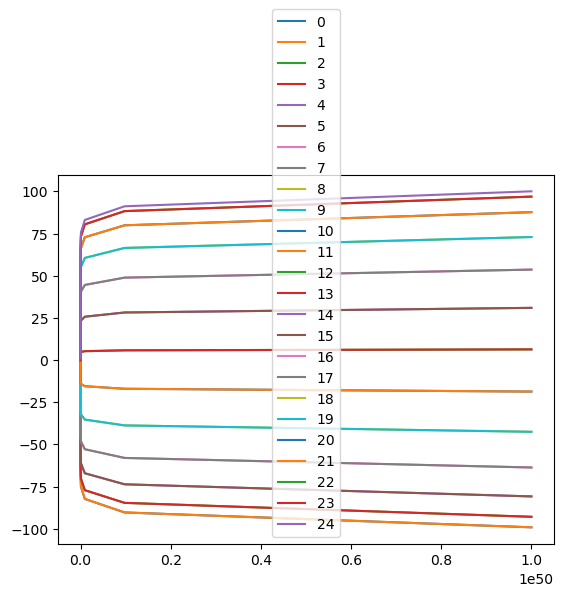

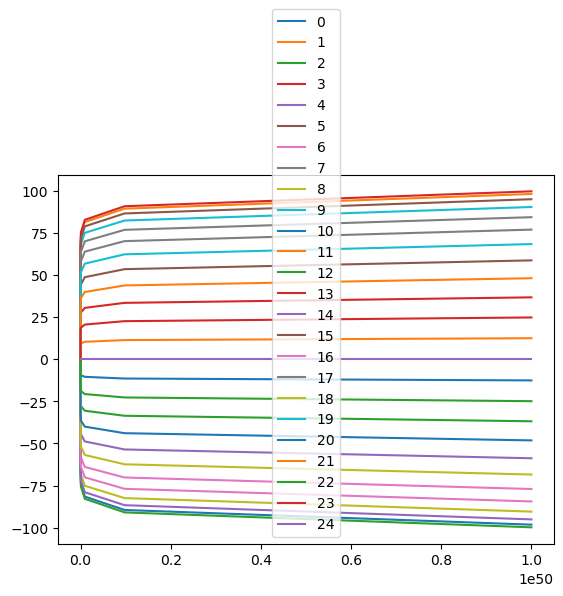

In [198]:
roots.apply(np.real).plot()
roots.apply(np.imag).plot()